# NequIP: Material Property Prediction Model Based on Equivariant Graph Neural Networks (MindSpore Implementation)

## Model Overview

**NequIP (Neural Equivariant Interatomic Potential)** is a molecular and materials modeling approach based on **E(3)-Equivariant Graph Neural Networks (E(3)-Equivariant GNNs)**.  
The model constructs a graph representation of atoms and ensures **rotation, translation, and reflection equivariance** during message passing.  
As a result, predictions remain consistent under 3D spatial transformations.  
Compared to traditional molecular potential energy surface models, NequIP achieves **higher data efficiency** and **better physical consistency**, enabling it to learn complex interatomic interactions from limited samples.

## Model Architecture

The core structure of NequIP consists of the following components:

- **Atomic Embedding Layer**: Maps discrete atom types into a continuous feature space.  
- **Equivariant Message Passing Layers**: Updates atomic features through radial basis functions and spherical harmonics, maintaining E(3) equivariance throughout.  
- **Energy/Force Head**: Aggregates per-atom energy contributions to compute the total energy of the system.

## Application Scenarios

NequIP can be applied to various atomistic modeling tasks, including:

- **Energy prediction** for molecular or crystalline systems;  
- **Force field prediction** for **molecular dynamics simulations**;  
- **Material property estimation**, such as binding energy, lattice constants, and band gap predictions.

In [1]:
import logging
import math
import os
import mindspore as ms
from mindspore import Profiler
from mindspore import nn
from src.dataset import create_training_dataset, _unpack

/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/zdai/miniconda3/envs/mindc_py39/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


In [2]:
import yaml
with open("./rmd.yaml", "r", encoding="utf-8") as f:
    configs = yaml.safe_load(f)

## Dataset Description: `rmd17_uracil.npz`

### Basic Information

- **Dataset Name**: `rmd17_uracil.npz`  
- **Source**: [Revised MD-17 (RMD-17)](https://figshare.com/articles/dataset/Revised_MD17_dataset_rMD17_/12672038)  
- **Target Molecule**: **Uracil**  
- **Format**: `.npz` (NumPy compressed archive)  
- **Number of Atoms**: 24 per configuration (including hydrogens)

---

### Dataset Overview

This dataset contains **atomic configurations** and corresponding **high-accuracy quantum mechanical energies and forces** for the Uracil molecule obtained from **molecular dynamics (MD) simulations**.  
It corrects inconsistencies in the original MD-17 dataset to provide **physically consistent energy-force pairs**.  

All configurations share a constant list of atomic numbers (`nuclear_charges`), making it suitable for:

- Molecular potential energy surface modeling  
- Machine Learning Force Field (MLFF) training  
- Graph Neural Network (GNN)-based joint energy and force prediction

---

### Data Fields in `.npz` File

| Field | Shape | Type | Description |
|-------|-------|------|-------------|
| `nuclear_charges` | `(24,)` | int | Atomic numbers (Z) for all atoms, shared across configurations |
| `coords` | `(N, 24, 3)` | float | Atomic coordinates for all configurations (in Å) |
| `energies` | `(N,)` | float | Scalar energy per configuration (in kcal/mol) |
| `forces` | `(N, 24, 3)` | float | Force vectors for each atom in each configuration (in kcal/mol/Å) |

---

### Model Input and Output Structure

#### Input Fields

| Field | Shape | Description |
|--------|--------|-------------|
| `x` | `(B * 24,)` | Atom type indices (int), derived from `nuclear_charges` for embedding |
| `pos` | `(B * 24, 3)` | Flattened atomic coordinates |
| `edge_index` | `(2, num_edges)` | Edge indices constructed via `radius_graph_full` (dynamically computed from `pos`) |
| `batch` | `(B * 24,)` | Batch index to separate configurations |

#### Output Target (`label → energy`)

| Field | Shape | Description |
|--------|--------|-------------|
| `energy` | `(B, 1)` | Normalized energy label |

---

### Custom Dataset Format

To use a custom dataset, ensure it contains the following fields:

```json
{
  "nuclear_charges": [6, 7, 8, 1, ...],
  "coords": [[[x, y, z], ...], ...],
  "energies": [...]
}

In [3]:
from src.dataset import create_training_dataset

data_params = configs.get('data')
trainset, train_edge_index, train_batch, evalset, eval_edge_index, eval_batch, num_type = create_training_dataset(
    config=data_params,
    dtype=ms.float32,
    pred_force=configs.get('pred_force')
)

print("Dataset loaded successfully")
print(f"Number of training samples: {data_params.get('n_train')}, Number of validation samples: {data_params.get('n_val')}")

Dataset loaded successfully
Number of training samples: 950, Number of validation samples: 50


NequIP Training Workflow

In [ ]:
import math
import logging
import os
import mindspore as ms
from mindspore import nn, Profiler
from src.dataset import _unpack, create_training_dataset
from models.nequip import Nequip
from tqdm.notebook import tqdm


def generate_learning_rate(learning_rate, warmup_steps, step_num):
    """Generate a learning rate schedule with warm-up and inverse square root decay."""
    warmup_scale = warmup_steps ** -1.5
    lr = []
    for s in range(1, step_num + 1):
        lr1 = s ** -0.5
        lr2 = s * warmup_scale
        lr.append(learning_rate * min(lr1, lr2))
    return lr


def train(dtype=ms.float32, configs=None):
    """NequIP training workflow"""
    data_params = configs.get('data')
    model_params = configs.get('model')
    optimizer_params = configs.get('optimizer')
    pred_force = configs.get('pred_force')
    is_profiling = configs.get('profiling')
    enable_mix_precision = configs.get('enable_mix_precision')
    ncon_dtype = ms.float16 if enable_mix_precision else ms.float32

    load_ckpt = configs.get('load_ckpt')
    load_ckpt_path = configs.get('load_ckpt_path')
    save_ckpt = configs.get('save_ckpt')
    save_ckpt_interval = configs.get('save_ckpt_interval')
    save_ckpt_path = configs.get('save_ckpt_path')
    if save_ckpt:
        os.makedirs(save_ckpt_path, exist_ok=True)

    logging.info('Loading dataset...')
    trainset, train_edge_index, train_batch, evalset, eval_edge_index, eval_batch, num_type = create_training_dataset(
        config=data_params, dtype=dtype, pred_force=configs.get('pred_force'))

    # ===== Model Initialization =====
    logging.info('Initializing NequIP model...')
    net = Nequip(
        irreps_embedding_out=model_params.get('irreps_embedding_out'),
        irreps_conv_out=model_params.get('irreps_conv_out'),
        chemical_embedding_irreps_out=model_params.get('chemical_embedding_irreps_out'),
        num_layers=model_params.get('num_layers'),
        num_type=num_type,
        r_max=model_params.get('r_max'),
        hidden_mul=model_params.get('hidden_mul'),
        pred_force=pred_force,
        dtype=dtype,
        ncon_dtype=ncon_dtype
    )

    if load_ckpt:
        logging.info('Loading checkpoint: %s', load_ckpt_path)
        ms.load_checkpoint(load_ckpt_path, net)

    # ===== Loss and Optimizer =====
    loss_fn = nn.MSELoss()
    metric_fn = nn.MAELoss()
    total_steps_num = optimizer_params.get('num_epoch') * math.ceil(
        data_params.get('n_train') / data_params.get('batch_size'))
    lr_schedule = generate_learning_rate(
        optimizer_params.get('learning_rate'),
        optimizer_params.get('warmup_steps'),
        total_steps_num
    )
    optimizer = nn.Adam(net.trainable_params(), learning_rate=lr_schedule,
                        use_amsgrad=optimizer_params.get('use_amsgrad'))

    # ===== Forward Computation =====
    def forward(batch, x, pos, edge_src, edge_dst, energy, force, batch_size, sep):
        pred = net(batch, x, pos, edge_src, edge_dst, batch_size)
        if pred_force:
            loss_energy = loss_fn(pred[0], energy)
            loss_force = loss_fn(pred[1], force)
            return loss_energy + 1000. * loss_force
        return loss_fn(pred, energy)

    backward = ms.value_and_grad(forward, None, optimizer.parameters)

    def train_step(batch, x, pos, edge_src, edge_dst, energy, force, size, sep):
        loss_, grads_ = backward(batch, x, pos, edge_src, edge_dst, energy, force, size, sep)
        optimizer(grads_)
        return loss_

    # ===== Validation Process =====
    def validation(eval_batch, eval_edge_index, evalset):
        dataset_size = evalset.get_dataset_size()
        total_eval, total_metric = 0, 0
        for _, data_dict_val in enumerate(evalset.create_dict_iterator()):
            batch_size_val = evalset.get_batch_size()
            inputs_val, label_val = _unpack(data_dict_val)
            pred = net(eval_batch, inputs_val[0], inputs_val[1],
                       eval_edge_index[0], eval_edge_index[1], batch_size_val)
            loss_val = loss_fn(pred, label_val[0]).asnumpy()
            metric = metric_fn(pred, label_val[0]).asnumpy()
            total_eval += loss_val
            total_metric += metric
        loss = total_eval / dataset_size
        metric_mean = total_metric / dataset_size
        logging.info('Eval loss: %8.8f   metric: %.8f', loss, metric_mean)
        return loss, metric_mean

    # ===== Start Training =====
    if is_profiling:
        profiler = Profiler(output_path="profiler_data")

    loss_train, loss_eval, metric = [], [], []
    eval_steps = optimizer_params.get('eval_steps')

    for epoch in range(optimizer_params.get('num_epoch')):
        epoch_loss = 0
        pbar = tqdm(
            total=trainset.get_dataset_size(),
            desc=f"Epoch {epoch+1}/{optimizer_params.get('num_epoch')}",
            leave=True  # Keep the bar after completion
        )
        for _, data_dict in enumerate(trainset.create_dict_iterator()):
            inputs, label = _unpack(data_dict)
            batch_size_train = trainset.get_batch_size()
            loss = train_step(train_batch, inputs[0], inputs[1],
                              train_edge_index[0], train_edge_index[1],
                              label[0], label[1], batch_size_train, False)
            epoch_loss += loss.asnumpy()
            pbar.update(1)
        pbar.close()
        epoch_loss = epoch_loss / trainset.get_dataset_size()
        loss_train.append(epoch_loss)

        if (epoch + 1) % eval_steps == 0:
            loss_val, metric_val = validation(eval_batch, eval_edge_index, evalset)
            loss_eval.append(loss_val)
            metric.append(metric_val)

        if save_ckpt and (epoch + 1) % save_ckpt_interval == 0:
            ms.save_checkpoint(net, f"{save_ckpt_path}/NequIP_rmd_{epoch}.ckpt")

    if is_profiling:
        profiler.analyse()
    if save_ckpt:
        ms.save_checkpoint(net, f"{save_ckpt_path}/NequIP_rmd.ckpt")

    print(f"Training completed. Total epochs: {optimizer_params.get('num_epoch')}")
    return loss_train, loss_eval, metric, lr_schedule


In [5]:
loss_train, loss_eval, metric, lr_schedule = train(dtype=ms.float32, configs=configs)


Epoch 1/2:   0%|          | 0/190 [00:00<?, ?it/s]

..

Epoch 2/2:   0%|          | 0/190 [00:00<?, ?it/s]

Training completed. Total epochs: 2


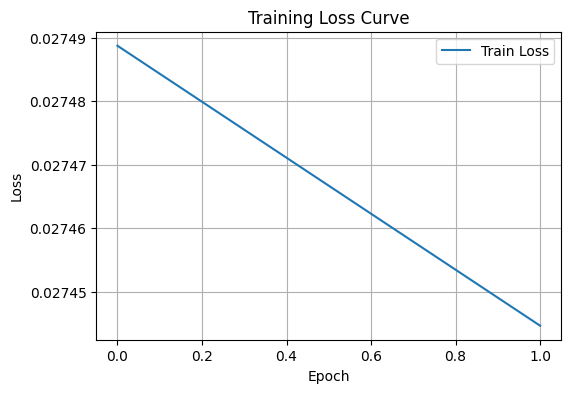

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(loss_train, label="Train Loss")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

predict

In [7]:
import traceback
import numpy as np


def evaluation_safe(dtype, configs):
    """
    Robust evaluation wrapper for notebook use.
    Returns: (pred_list, loss_mean, metric_mean) or (None, None, None) on error.
    Prints diagnostic info and full traceback on exceptions.
    """
    try:
        # ---- basic checks ----
        if configs is None:
            print("[ERROR] configs is None")
            return None, None, None
        data_params = configs.get('data', {})
        model_params = configs.get('model', {})
        pred_force = configs.get('pred_force', False)
        load_ckpt_path = configs.get('load_ckpt_path')
        save_path = data_params.get('save_path', "./pred_results")
        os.makedirs(save_path, exist_ok=True)

        print("[INFO] dtype:", dtype)
        print("[INFO] load_ckpt_path:", load_ckpt_path)
        if load_ckpt_path is None or not os.path.exists(load_ckpt_path):
            print(f"[ERROR] checkpoint not found at: {load_ckpt_path}")
            print("-> please set configs['load_ckpt_path'] to a valid .ckpt file path")
            return None, None, None

        # ---- load evaluation dataset ----
        print("[INFO] Creating evaluation dataset...")
        _, _, _, evalset, eval_edge_index, eval_batch, num_type = create_training_dataset(
            config=data_params, dtype=dtype, pred_force=pred_force)

        print("[INFO] Eval dataset size:", evalset.get_dataset_size())
        print("[INFO] Eval batch size:", evalset.get_batch_size())
        print("[INFO] num_type:", num_type)

        # ---- build model ----
        print("[INFO] Initializing model...")
        net = Nequip(
            irreps_embedding_out=model_params.get('irreps_embedding_out'),
            irreps_conv_out=model_params.get('irreps_conv_out'),
            chemical_embedding_irreps_out=model_params.get('chemical_embedding_irreps_out'),
            num_layers=model_params.get('num_layers'),
            num_type=num_type,
            r_max=model_params.get('r_max'),
            hidden_mul=model_params.get('hidden_mul'),
            pred_force=pred_force,
            dtype=dtype,
        )

        # ---- load checkpoint ----
        try:
            print(f"[INFO] Loading checkpoint from {load_ckpt_path} ...")
            ms.load_checkpoint(load_ckpt_path, net)
            print("[INFO] Checkpoint loaded successfully.")
        except Exception as e_ckpt:
            print("[ERROR] Failed to load checkpoint:",e_ckpt)
            traceback.print_exc()
            return None, None, None

        loss_fn = nn.MSELoss()
        metric_fn = nn.MAELoss()

        # ---- evaluation loop ----
        dataset_size = evalset.get_dataset_size()
        print("[INFO] Starting evaluation loop...")
        total_loss = total_metric = 0.0
        total_loss_energy = total_loss_force = 0.0
        total_metric_energy = total_metric_force = 0.0

        pred_list = []
        pred_energy_list = []
        pred_force_list=[]
        true_energy_list, true_list = [], []

        for idx, data_dict_val in enumerate(evalset.create_dict_iterator()):
            try:
                batch_size_val = evalset.get_batch_size()
                inputs_val, label_val = _unpack(data_dict_val)

                # Forward (ensure shapes / types)
                pred = net(eval_batch, inputs_val[0], inputs_val[1],
                           eval_edge_index[0], eval_edge_index[1], batch_size_val)

                if not pred_force:
                    loss = loss_fn(pred, label_val[0]).asnumpy()
                    metric = metric_fn(pred, label_val[0]).asnumpy()
                    total_loss += float(loss)
                    total_metric += float(metric)
                    pred_list.append(pred.asnumpy())
                    true_list.append(label_val[0].asnumpy())
                else:
                    loss_energy = float(loss_fn(pred[0], label_val[0]).asnumpy())
                    loss_force = float(loss_fn(pred[1], label_val[1]).asnumpy())
                    metric_energy = float(metric_fn(pred[0], label_val[0]).asnumpy())
                    metric_force = float(metric_fn(pred[1], label_val[1]).asnumpy())
                    total_loss_energy += loss_energy
                    total_loss_force += loss_force
                    total_metric_energy += metric_energy
                    total_metric_force += metric_force
                    pred_energy_list.append(pred[0].asnumpy())
                    pred_force_list.append(pred[1].asnumpy())
                    true_energy_list.append(label_val[0].asnumpy())
            except Exception as e_batch:
                print(f"[ERROR] Exception during eval loop at batch {idx}:",e_batch)
                traceback.print_exc()
                # continue to next batch (or return depending on your preference)
                return None, None, None
        print("pred_list: ", pred_list)
        # ---- summarize and save ----
        if not pred_force:
            loss_mean = total_loss / dataset_size
            metric_mean = total_metric / dataset_size
            np.save(os.path.join(save_path, configs["data"]["pred_file"]), pred_list)
            np.save(os.path.join(save_path, configs["data"]["true_file"]), true_list)
            print("[INFO] Predictions and true values saved to:", save_path)
            print(f"[RESULT] loss_mean: {loss_mean:.8f}  metric_mean: {metric_mean:.8f}")
            return pred_list, loss_mean, metric_mean
        loss_mean = (total_loss_energy / dataset_size, total_loss_force / dataset_size)
        metric_mean = (total_metric_energy / dataset_size, total_metric_force / dataset_size)
        np.save(os.path.join(save_path, configs["data"]["pred_energy_file"]), pred_energy_list)
        np.save(os.path.join(save_path, configs["data"]["true_energy_file"]), true_energy_list)
        print(f"[RESULT] loss_energy_mean: {loss_mean[0]:.8f}  loss_force_mean: {loss_mean[1]:.8f}")
        print(f"[RESULT] metric_energy_mean: {metric_mean[0]:.8f}  metric_force_mean: {metric_mean[1]:.8f}")
        return [pred_energy_list, pred_force_list], loss_mean, metric_mean

    except Exception as e:
        print("[FATAL] Unexpected exception in evaluation_safe:",e)
        traceback.print_exc()
        return None, None, None


In [8]:
pred_list, loss_mean, metric_mean = evaluation_safe(ms.float32, configs)
print("Returned:", pred_list is not None, loss_mean, metric_mean)

[INFO] dtype: Float32
[INFO] load_ckpt_path: ./checkpoints/NequIP_rmd.ckpt
[INFO] Creating evaluation dataset...
[INFO] Eval dataset size: 10
[INFO] Eval batch size: 5
[INFO] num_type: 4
[INFO] Initializing model...
[INFO] Loading checkpoint from ./checkpoints/NequIP_rmd.ckpt ...
[INFO] Checkpoint loaded successfully.
[INFO] Starting evaluation loop...
pred_list:  [array([[0.01096154],
       [0.01152363],
       [0.0088922 ],
       [0.00950281],
       [0.00832928]], dtype=float32), array([[0.00859195],
       [0.0075928 ],
       [0.00821682],
       [0.0109686 ],
       [0.00735036]], dtype=float32), array([[0.01072005],
       [0.00882987],
       [0.00881849],
       [0.00874563],
       [0.01059538]], dtype=float32), array([[0.00778127],
       [0.00994838],
       [0.00931875],
       [0.0101115 ],
       [0.01051392]], dtype=float32), array([[0.0080817 ],
       [0.00788514],
       [0.00946121],
       [0.00925998],
       [0.01006626]], dtype=float32), array([[0.00661376],
 

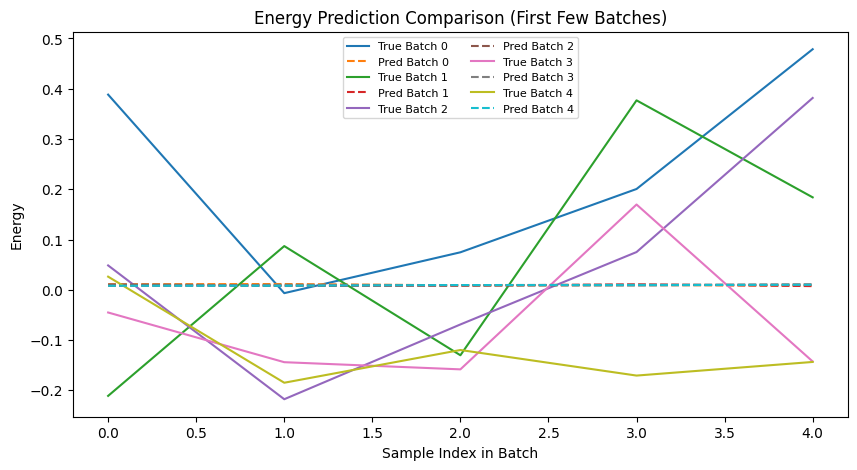

In [9]:
# The plot below shows noticeable trends only after training for around 200 epochs.
# Here, we use a smaller number of epochs for quick verification.
import matplotlib.pyplot as plt
import numpy as np

pred_energy = np.load("./results/pred.npy", allow_pickle=True)
true_energy = np.load("./results/true.npy", allow_pickle=True)

# Plot comparison between predicted and true energy values
plt.figure(figsize=(10, 5))
num_batches_to_show = min(5, len(pred_energy))  # Display only the first 5 batches

for i in range(num_batches_to_show):
    plt.plot(true_energy[i][:50], label=f"True Batch {i}")
    plt.plot(pred_energy[i][:50], "--", label=f"Pred Batch {i}")

plt.title("Energy Prediction Comparison (First Few Batches)")
plt.xlabel("Sample Index in Batch")
plt.ylabel("Energy")
plt.legend(ncol=2, fontsize=8)
plt.show()


{'pred_force': False, 'profiling': False, 'load_ckpt': False, 'load_ckpt_path': './checkpoints/NequIP_rmd.ckpt', 'save_ckpt': True, 'save_ckpt_interval': 200, 'save_ckpt_path': './checkpoints', 'enable_mix_precision': False, 'model': {'irreps_embedding_out': '16x0e', 'irreps_conv_out': '64x0o+64x0e+64x1o+64x1e+64x2o+64x2e', 'chemical_embedding_irreps_out': '64x0e', 'num_layers': 5, 'num_type': 4, 'r_max': 4, 'hidden_mul': 64}, 'optimizer': {'num_epoch': 2, 'eval_steps': 10, 'warmup_steps': 6400, 'learning_rate': 0.01, 'use_amsgrad': True}, 'data': {'name': 'nequip', 'path': './dataset/MD17/npz_data/rmd17_uracil.npz', 'save_path': './results', 'n_train': 950, 'n_val': 50, 'batch_size': 5, 'save_pred': True, 'save_true': True, 'pred_file': 'pred.npy', 'true_file': 'true.npy'}}
./dataset/MD17/npz_data/rmd17_uracil.npz


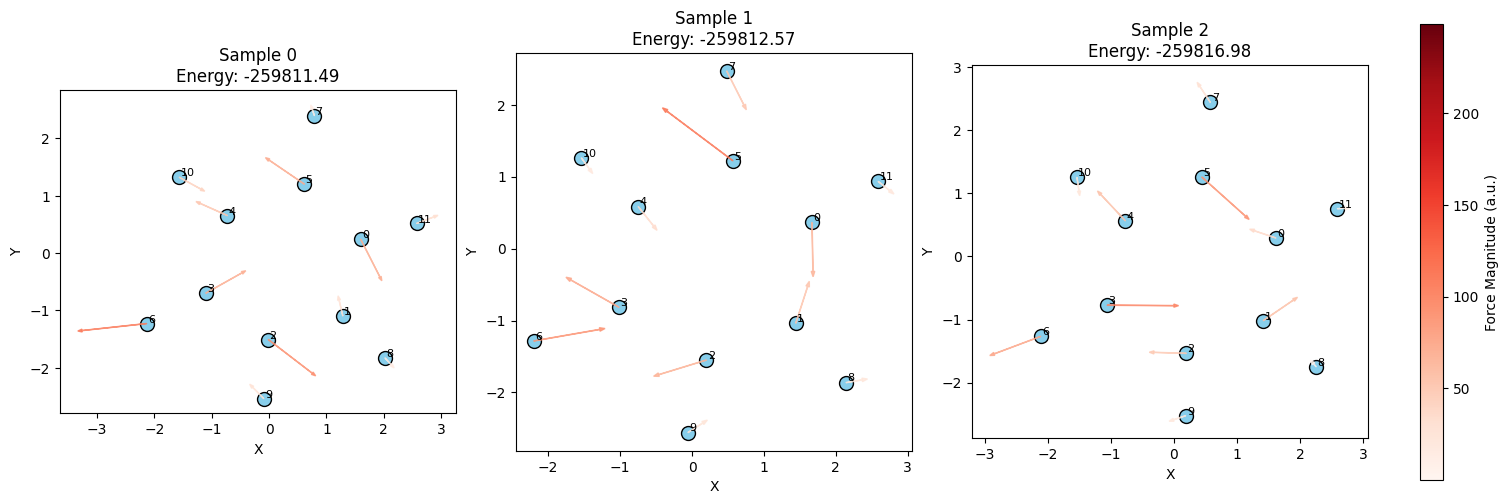

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data_path = configs['data'].get("path", None)  # Dataset path
print(configs)
print(data_path)
data = np.load(data_path, allow_pickle=True)

# Select the first 3 samples for visualization
num_samples_to_plot = 3
coords = data['coords']
forces = data['forces']
energies = data['energies']

# Compute the overall range of force magnitudes for consistent color mapping
all_force_mags = np.linalg.norm(forces[:, :, :2], axis=2)
vmin, vmax = all_force_mags.min(), all_force_mags.max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.Reds

# Create 3 side-by-side subplots
fig, axes = plt.subplots(1, num_samples_to_plot, figsize=(15, 5), constrained_layout=True)

for i, ax in enumerate(axes):
    xy_coords = coords[i][:, :2]
    force_xy = forces[i][:, :2]
    force_mags = np.linalg.norm(force_xy, axis=1)
    colors = cmap(norm(force_mags))

    # Plot atom positions
    ax.scatter(xy_coords[:, 0], xy_coords[:, 1], s=100, c='skyblue', edgecolors='k', label='Atoms')

    # Plot force vectors (colored by magnitude)
    scale = 0.01
    for j in range(xy_coords.shape[0]):
        ax.arrow(xy_coords[j, 0], xy_coords[j, 1],
                 force_xy[j, 0] * scale, force_xy[j, 1] * scale,
                 color=colors[j], width=0.004, head_width=0.05, alpha=0.8)

    # Atom indices
    for j, (x, y) in enumerate(xy_coords):
        ax.text(x + 0.02, y + 0.02, str(j), fontsize=8)

    ax.set_aspect('equal')
    ax.set_title(f"Sample {i}\nEnergy: {energies[i]:.2f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

# Add color bar (force magnitude)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                    ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("Force Magnitude (a.u.)")

plt.show()
